# Cytotoxicity Dataset: EDA and Baseline Models

Exploratory analysis of the combined cytotoxicity classification dataset, then baseline models built up one at a time: Logistic Regression → Random Forest → XGBoost → TabPFN → CheMeleon → DeepTox-style DNN.

## 1. Setup and load data

Note: as of this run, `data/combined/` contains **Tox21 + ToxCast only** — GDSC is still being resolved in the background (drug-name → PubChem CID lookup) and will be folded in once ready. Re-run this cell after that to pick it up automatically.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

REPO_ROOT = "/nethome/akarimi/ak_repos_github/cytotoxicity-dataset-collection"
df = pd.read_csv(f"{REPO_ROOT}/data/combined/combined_cytotoxicity_classification.csv")
print(df.shape)
df.head()

(15476, 14)


,source,biological_context,cid,canonical_smiles,isomeric_smiles,molecular_formula,molecular_weight,cytotoxic_label,potency_value,potency_metric,potency_unit,n_assays_active,n_assays_tested,assay_description
0,Tox21,off-target-safety,4,CC(CN)O,CC(CN)O,C3H9NO,75.11,0.0,NaN,AC50,uM,0.0,4.0,RealTime-Glo MT Cell Viability + CellTox Green...
1,Tox21,off-target-safety,6,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,C6H3ClN2O4,202.55,1.0,9.9244,AC50,uM,8.0,8.0,RealTime-Glo MT Cell Viability + CellTox Green...
2,Tox21,off-target-safety,11,C(CCl)Cl,C(CCl)Cl,C2H4Cl2,98.96,0.0,NaN,AC50,uM,0.0,4.0,RealTime-Glo MT Cell Viability + CellTox Green...
3,Tox21,off-target-safety,13,C1=CC(=C(C=C1Cl)Cl)Cl,C1=CC(=C(C=C1Cl)Cl)Cl,C6H3Cl3,181.40,0.0,NaN,AC50,uM,0.0,8.0,RealTime-Glo MT Cell Viability + CellTox Green...
4,Tox21,off-target-safety,33,C(C=O)Cl,C(C=O)Cl,C2H3ClO,78.50,0.0,NaN,AC50,uM,0.0,4.0,RealTime-Glo MT Cell Viability + CellTox Green...


## 2. Source and biological context breakdown

Recall: `biological_context` distinguishes off-target safety toxicity (Tox21/ToxCast) from on-target cancer-efficacy killing (GDSC and future additions) — these should not be pooled into one label without accounting for this.

In [2]:
print(df.groupby(["source", "biological_context"]).size())
print()
print("Rows with missing SMILES:", df["canonical_smiles"].isna().sum())
print("Unique compounds (CID) overall:", df["cid"].nunique())
print("Unique compounds per source:")
print(df.groupby("source")["cid"].nunique())

source   biological_context
Tox21    off-target-safety     7671
ToxCast  off-target-safety     7805
dtype: int64

Rows with missing SMILES: 0
Unique compounds (CID) overall: 9147
Unique compounds per source:
source
Tox21      7671
ToxCast    7762
Name: cid, dtype: int64


## 3. Class balance — overall and by source

`cytotoxic_label` has NaN rows (inconclusive, Tox21 only) — drop those before any modeling.

Rows usable for modeling (non-null label + SMILES): 14105 / 15476


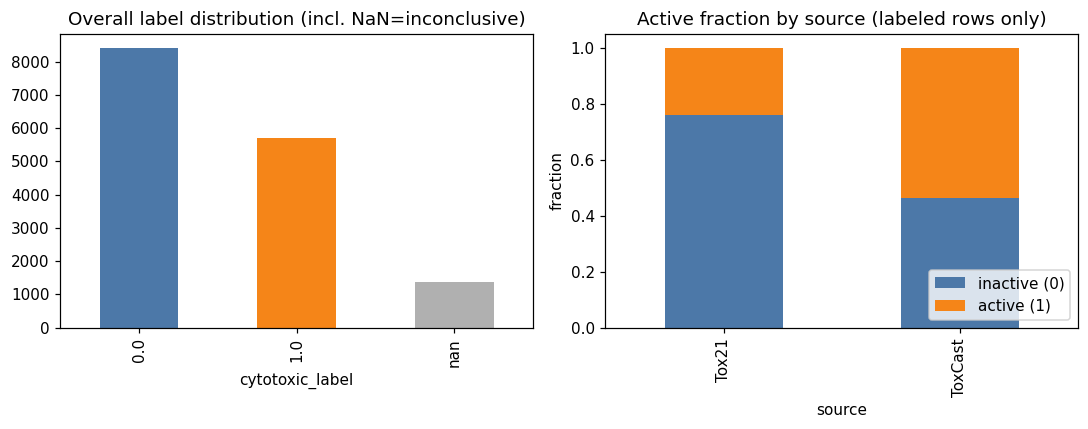

cytotoxic_label     0     1
source                     
Tox21            4788  1512
ToxCast          3621  4184


In [3]:
labeled = df.dropna(subset=["cytotoxic_label", "canonical_smiles"]).copy()
labeled["cytotoxic_label"] = labeled["cytotoxic_label"].astype(int)
print(f"Rows usable for modeling (non-null label + SMILES): {len(labeled)} / {len(df)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["cytotoxic_label"].value_counts(dropna=False).sort_index().plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#B0B0B0"])
axes[0].set_title("Overall label distribution (incl. NaN=inconclusive)")
axes[0].set_xlabel("cytotoxic_label")

ct = pd.crosstab(labeled["source"], labeled["cytotoxic_label"], normalize="index")
ct.plot(kind="bar", stacked=True, ax=axes[1], color=["#4C78A8", "#F58518"])
axes[1].set_title("Active fraction by source (labeled rows only)")
axes[1].set_ylabel("fraction")
axes[1].legend(["inactive (0)", "active (1)"], loc="lower right")
plt.tight_layout()
plt.show()

print(pd.crosstab(labeled["source"], labeled["cytotoxic_label"]))

## 4. Molecular weight distribution by source

Sanity check on chemical space differences between the toxicology-screening sources (broad chemical libraries) and cancer-pharmacology sources (targeted drug libraries, once GDSC is added).

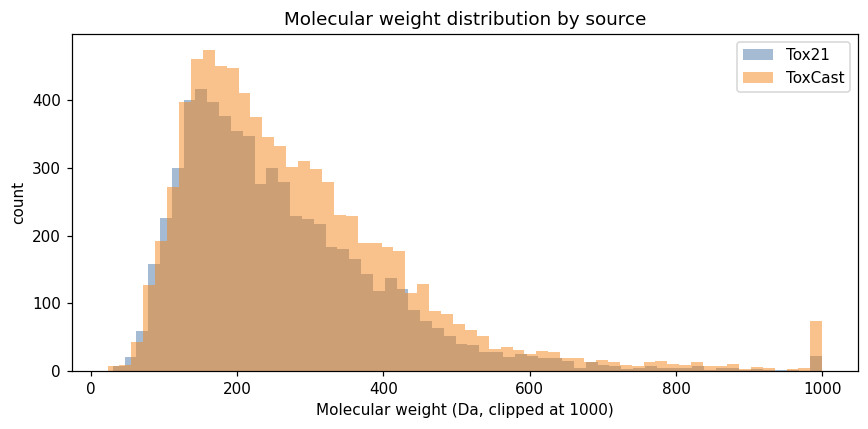

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
Tox21,6300.0,263.050272,147.452021,30.026000,158.28,229.07,331.575,1550.2
ToxCast,7805.0,285.812456,181.594975,22.989769,168.19,245.66,354.500,3326.8


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for src, color in zip(labeled["source"].unique(), ["#4C78A8", "#F58518", "#54A24B"]):
    subset = labeled.loc[labeled["source"] == src, "molecular_weight"].dropna()
    ax.hist(subset.clip(upper=1000), bins=60, alpha=0.5, label=src, color=color)
ax.set_xlabel("Molecular weight (Da, clipped at 1000)")
ax.set_ylabel("count")
ax.legend()
ax.set_title("Molecular weight distribution by source")
plt.tight_layout()
plt.show()

labeled.groupby("source")["molecular_weight"].describe()

## 5. Cross-source compound overlap

Same CID appearing under multiple sources means it carries a different label depending on which biological question was asked — worth knowing how much of the dataset this affects.

In [5]:
sources = labeled["source"].unique().tolist()
for i in range(len(sources)):
    for j in range(i + 1, len(sources)):
        a, b = sources[i], sources[j]
        cids_a = set(labeled.loc[labeled["source"] == a, "cid"])
        cids_b = set(labeled.loc[labeled["source"] == b, "cid"])
        overlap = cids_a & cids_b
        print(f"{a} ({len(cids_a)}) vs {b} ({len(cids_b)}): {len(overlap)} shared CIDs")

# For CIDs shared between two sources, how often do the labels actually disagree?
if len(sources) >= 2:
    pivot = labeled.pivot_table(index="cid", columns="source", values="cytotoxic_label", aggfunc="first")
    pair_cols = [c for c in pivot.columns if c in sources]
    if len(pair_cols) == 2:
        both = pivot.dropna(subset=pair_cols)
        agree = (both[pair_cols[0]] == both[pair_cols[1]]).mean()
        print(f"\nOf {len(both)} compounds labeled in both {pair_cols[0]} and {pair_cols[1]}: {agree:.1%} label agreement")

Tox21 (6300) vs ToxCast (7762): 5155 shared CIDs

Of 5155 compounds labeled in both Tox21 and ToxCast: 72.3% label agreement


### EDA takeaways

- **14,105 / 15,476 rows usable** (drop NaN labels — Tox21 inconclusive — and any missing SMILES).
- **Class balance differs sharply by source**: Tox21 ~20% active, ToxCast ~54% active — a model must not treat `source` as a nuisance column; it's informative and should be a feature or a stratification key.
- **5,155 compounds (CID) are shared** between Tox21 and ToxCast, but their labels agree only **72.3% of the time** — the two panels are measuring related but genuinely different things (dedicated 4-assay viability panel vs. cross-target burst pattern across ~86 assays), confirming they shouldn't be silently merged into one ground truth.
- Molecular weight distributions are similar between Tox21/ToxCast (both broad chemical libraries); this will likely diverge once GDSC (targeted oncology drugs) is added.

## 6. Featurization: Morgan fingerprints

Baseline models (LogReg, RF, XGBoost, TabPFN) will use ECFP4-style Morgan fingerprints (radius=2, 2048 bits) computed from `canonical_smiles` via RDKit. CheMeleon and the DeepTox-style DNN use their own representations (message-passing graph / a wider feature set respectively), built in their own sections later.

In [6]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

FP_RADIUS, FP_BITS = 2, 2048
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_BITS)

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array(fp_gen.GetFingerprint(mol))

unique_smiles = labeled["canonical_smiles"].unique()
fp_cache = {}
n_failed = 0
for smi in unique_smiles:
    fp = smiles_to_fp(smi)
    if fp is None:
        n_failed += 1
    fp_cache[smi] = fp

print(f"Featurized {len(unique_smiles) - n_failed}/{len(unique_smiles)} unique structures ({n_failed} failed to parse)")

labeled["_fp"] = labeled["canonical_smiles"].map(fp_cache)
model_df = labeled.dropna(subset=["_fp"]).reset_index(drop=True)
print(f"Rows with a usable fingerprint: {len(model_df)}")

Featurized 8621/8621 unique structures (0 failed to parse)
Rows with a usable fingerprint: 14105


## 7. Train/test split

Split **grouped by `cid`**, not randomly by row — since a compound shared between Tox21 and ToxCast produces two rows, a plain random split could leak the same molecule into both train and test under different `source` rows. `StratifiedGroupKFold` keeps groups intact while still balancing `cytotoxic_label` across the split.

In [7]:
from sklearn.model_selection import StratifiedGroupKFold

X = np.stack(model_df["_fp"].values)
y = model_df["cytotoxic_label"].values
groups = model_df["cid"].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
meta_train, meta_test = model_df.iloc[train_idx], model_df.iloc[test_idx]

assert set(meta_train["cid"]) & set(meta_test["cid"]) == set(), "compound leakage between train/test!"

print(f"Train: {len(X_train)} rows ({y_train.mean():.1%} active), {meta_train['cid'].nunique()} unique compounds")
print(f"Test:  {len(X_test)} rows ({y_test.mean():.1%} active), {meta_test['cid'].nunique()} unique compounds")
print("\nTrain source breakdown:\n", meta_train["source"].value_counts())
print("\nTest source breakdown:\n", meta_test["source"].value_counts())

# results table to accumulate metrics from every model in this notebook
results = []

Train: 11280 rows (40.2% active), 7127 unique compounds
Test:  2825 rows (41.2% active), 1780 unique compounds

Train source breakdown:
 source
ToxCast    6242
Tox21      5038
Name: count, dtype: int64

Test source breakdown:
 source
ToxCast    1563
Tox21      1262
Name: count, dtype: int64


In [8]:
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score

def evaluate(name, y_true, y_prob, meta):
    y_pred = (y_prob >= 0.5).astype(int)
    row = {
        "model": name,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }
    # per-source breakdown, since class balance differs sharply by source (see EDA)
    for src in meta["source"].unique():
        mask = (meta["source"] == src).values
        if mask.sum() > 0 and len(np.unique(y_true[mask])) > 1:
            row[f"roc_auc_{src}"] = roc_auc_score(y_true[mask], y_prob[mask])
    results.append(row)
    print(f"{name}: ROC-AUC={row['roc_auc']:.3f}  PR-AUC={row['pr_auc']:.3f}  "
          f"balanced_acc={row['balanced_accuracy']:.3f}  F1={row['f1']:.3f}")
    for src in meta["source"].unique():
        k = f"roc_auc_{src}"
        if k in row:
            print(f"    {src} ROC-AUC: {row[k]:.3f}")
    return row

## 8. Model 1 — Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
logreg.fit(X_train, y_train)
y_prob_logreg = logreg.predict_proba(X_test)[:, 1]
_ = evaluate("LogisticRegression", y_test, y_prob_logreg, meta_test)

LogisticRegression: ROC-AUC=0.709  PR-AUC=0.631  balanced_acc=0.664  F1=0.614
    Tox21 ROC-AUC: 0.763
    ToxCast ROC-AUC: 0.702


## 9. Model 2 — Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500, max_depth=None, class_weight="balanced_subsample",
    n_jobs=-1, random_state=42,
)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
_ = evaluate("RandomForest", y_test, y_prob_rf, meta_test)

RandomForest: ROC-AUC=0.740  PR-AUC=0.697  balanced_acc=0.681  F1=0.607
    Tox21 ROC-AUC: 0.812
    ToxCast ROC-AUC: 0.732


## 10. Model 3 — XGBoost

In [11]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", n_jobs=-1, random_state=42,
)
xgb_clf.fit(X_train, y_train)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]
_ = evaluate("XGBoost", y_test, y_prob_xgb, meta_test)

XGBoost: ROC-AUC=0.741  PR-AUC=0.687  balanced_acc=0.684  F1=0.631
    Tox21 ROC-AUC: 0.807
    ToxCast ROC-AUC: 0.735


## 11. Model 4 — TabPFN (skipped)

**Blocked, not implemented**: as of this run, TabPFN (Prior Labs) requires a one-time license
acceptance and API token (`TABPFN_TOKEN`) obtained via an interactive browser login at
https://ux.priorlabs.ai before it will download model weights for local inference — this can't be
done non-interactively. To pick this back up: register there, accept the license, copy the API
key, `export TABPFN_TOKEN="..."` (or `os.environ["TABPFN_TOKEN"] = "..."` before `.fit()`), then
uncomment and run the cell below. The featurization plan (PCA to 100 components, subsample train
to 3,000 rows, stratified) is unchanged and already accounts for TabPFN's pretraining-regime
limits.

In [12]:
# SKIPPED — see markdown above. Uncomment once TABPFN_TOKEN is set.

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier
import os
from dotenv import load_dotenv

load_dotenv()

TABPFN_MAX_TRAIN = 3000
TABPFN_N_COMPONENTS = 100

pca = PCA(n_components=TABPFN_N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
print(f"PCA explained variance ratio (sum of {TABPFN_N_COMPONENTS} components): {pca.explained_variance_ratio_.sum():.3f}")

if len(X_train_pca) > TABPFN_MAX_TRAIN:
    X_train_tab, _, y_train_tab, _ = train_test_split(
        X_train_pca, y_train, train_size=TABPFN_MAX_TRAIN, stratify=y_train, random_state=42,
    )
else:
    X_train_tab, y_train_tab = X_train_pca, y_train
print(f"TabPFN training subsample: {len(X_train_tab)} rows ({y_train_tab.mean():.1%} active)")

tabpfn_clf = TabPFNClassifier(device="auto", random_state=42, ignore_pretraining_limits=True)
tabpfn_clf.fit(X_train_tab, y_train_tab)
y_prob_tabpfn = tabpfn_clf.predict_proba(X_test_pca)[:, 1]
_ = evaluate("TabPFN", y_test, y_prob_tabpfn, meta_test)
print("TabPFN skipped — needs TABPFN_TOKEN, see markdown above.")

PCA explained variance ratio (sum of 100 components): 0.536
TabPFN training subsample: 3000 rows (40.2% active)
TabPFN: ROC-AUC=0.711  PR-AUC=0.650  balanced_acc=0.651  F1=0.541
    Tox21 ROC-AUC: 0.770
    ToxCast ROC-AUC: 0.707
TabPFN skipped — needs TABPFN_TOKEN, see markdown above.


## 12. Model 5 — CheMeleon

[CheMeleon](https://github.com/JacksonBurns/chemeleon) is a D-MPNN foundation model pretrained on
1M PubChem molecules to predict Mordred descriptors, bundled into `chemprop` (`--from-foundation
CHEMELEON`). Unlike the fingerprint-based models above, it takes SMILES directly as a molecular
graph, learns its own representation, and is fine-tuned end-to-end on our label — so it gets its
own train/val/test CSVs rather than reusing `X_train`/`X_test`. Val is carved out of the training
compounds only (same `StratifiedGroupKFold` grouping-by-`cid` logic as the main split), so the
true test set stays untouched until prediction.

Runs via the `chemprop` CLI (subprocess), since that's how foundation-model fine-tuning is
exposed — there's no equivalent stable Python API for `--from-foundation` yet.

In [13]:
import os

CHEMPROP_DIR = f"{REPO_ROOT}/notebooks/_chemprop_run"
os.makedirs(CHEMPROP_DIR, exist_ok=True)

# Carve a val split out of the training compounds only (grouped by cid) — test set untouched.
sgkf_val = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
tr_sub_idx, val_idx = next(sgkf_val.split(meta_train, y_train, meta_train["cid"].values))

train_csv = meta_train.iloc[tr_sub_idx][["canonical_smiles", "cytotoxic_label"]]
val_csv = meta_train.iloc[val_idx][["canonical_smiles", "cytotoxic_label"]]
test_csv = meta_test[["canonical_smiles", "cytotoxic_label"]]

train_csv.to_csv(f"{CHEMPROP_DIR}/train.csv", index=False)
val_csv.to_csv(f"{CHEMPROP_DIR}/val.csv", index=False)
test_csv.to_csv(f"{CHEMPROP_DIR}/test.csv", index=False)
print(f"train={len(train_csv)}  val={len(val_csv)}  test={len(test_csv)}")

train=10143  val=1137  test=2825


In [14]:
# NOT RUN HERE — fine-tuning left for manual execution (D-MPNN training is slow on CPU and best
# driven interactively). CSVs above are ready; run from notebooks/_chemprop_run/:
#
  # chemprop train \
  #   -i train.csv val.csv \
  #   -s canonical_smiles --target-columns cytotoxic_label --task-type classification \
  #   --from-foundation CHEMELEON \
  #   --epochs 30 --split-sizes 0.9 0.1 0.0 \
  #   -o chemeleon_run

  # chemprop predict \
  #   -i test.csv -s canonical_smiles \
  #   --model-paths chemeleon_run/model_0/best.pt \
  #   -o chemeleon_preds.csv
#
# Then load chemeleon_preds.csv and call evaluate("CheMeleon", y_test, preds, meta_test) to slot
# it into the results table alongside the other models.
print("CheMeleon: CSVs prepared in", CHEMPROP_DIR, "— fine-tuning left for manual run, see comment above.")

CheMeleon: CSVs prepared in /nethome/akarimi/ak_repos_github/cytotoxicity-dataset-collection/notebooks/_chemprop_run — fine-tuning left for manual run, see comment above.


In [15]:
chemeleon_preds_path = f"{CHEMPROP_DIR}/chemeleon_preds.csv"

if os.path.exists(chemeleon_preds_path):
    chemeleon_out = pd.read_csv(chemeleon_preds_path)

    assert len(chemeleon_out) == len(meta_test), "row count mismatch -- did test.csv change?"
    y_prob_chemeleon = chemeleon_out['cytotoxic_label'].values
    y_true_chemeleon = meta_test['cytotoxic_label'].values

    _ = evaluate("CheMeleon", y_true_chemeleon, y_prob_chemeleon, meta_test)
else:
    print(f'Not found: {chemeleon_preds_path} - run the chemprop train/predict commands above first.')

CheMeleon: ROC-AUC=0.766  PR-AUC=0.708  balanced_acc=0.697  F1=0.634
    Tox21 ROC-AUC: 0.829
    ToxCast ROC-AUC: 0.767


## 13. Model 6 — DeepTox-style DNN

[DeepTox](https://doi.org/10.3389/fenvs.2015.00080) (Mayr et al. 2016) won the original Tox21 Data
Challenge — a multi-task deep neural net trained on a combination of static chemical descriptors
and fingerprint-based features. There's no pip-installable DeepTox package (the original was
Lua/Theano); this is a **faithful reimplementation of the core idea** in PyTorch, not the original
codebase: Morgan fingerprints concatenated with classic RDKit physicochemical descriptors (MW,
LogP, TPSA, H-bond donors/acceptors, rotatable bonds, aromatic ring count), fed through a
dropout-regularized feedforward network, trained single-task on our label (the original was
multi-task across all 12 Tox21 Challenge assays — not applicable here since we only have one
cytotoxicity target per source).

In [16]:
from rdkit.Chem import Descriptors

DESCRIPTOR_FUNCS = {
    "MolWt": Descriptors.MolWt,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "NumAromaticRings": Descriptors.NumAromaticRings,
    "RingCount": Descriptors.RingCount,
    "FractionCSP3": Descriptors.FractionCSP3,
    "NumHeteroatoms": Descriptors.NumHeteroatoms,
}

def smiles_to_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array([f(mol) for f in DESCRIPTOR_FUNCS.values()], dtype=np.float32)

desc_cache = {smi: smiles_to_descriptors(smi) for smi in unique_smiles}

desc_train_raw = np.stack([desc_cache[s] for s in meta_train["canonical_smiles"]])
desc_test_raw = np.stack([desc_cache[s] for s in meta_test["canonical_smiles"]])

from sklearn.preprocessing import StandardScaler
desc_scaler = StandardScaler()
desc_train = desc_scaler.fit_transform(desc_train_raw)
desc_test = desc_scaler.transform(desc_test_raw)

X_train_dt = np.concatenate([X_train, desc_train], axis=1).astype(np.float32)
X_test_dt = np.concatenate([X_test, desc_test], axis=1).astype(np.float32)
print(f"DeepTox feature matrix: train={X_train_dt.shape}  test={X_test_dt.shape}  "
      f"({X_train.shape[1]} FP bits + {desc_train.shape[1]} descriptors)")

DeepTox feature matrix: train=(11280, 2058)  test=(2825, 2058)  (2048 FP bits + 10 descriptors)


In [17]:
import torch
import torch.nn as nn

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

class DeepToxDNN(nn.Module):
    def __init__(self, in_dim, hidden_dims=(512, 128), dropout=0.5):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

model = DeepToxDNN(in_dim=X_train_dt.shape[1]).to(device)
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

Xt = torch.tensor(X_train_dt, device=device)
yt = torch.tensor(y_train, dtype=torch.float32, device=device)
Xv = torch.tensor(X_test_dt, device=device)

BATCH_SIZE, N_EPOCHS = 128, 30
n = len(Xt)
for epoch in range(N_EPOCHS):
    model.train()
    perm = torch.randperm(n)
    epoch_loss = 0.0
    for i in range(0, n, BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        optimizer.zero_grad()
        logits = model(Xt[idx])
        loss = criterion(logits, yt[idx])
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"epoch {epoch+1}/{N_EPOCHS}  loss={epoch_loss/n:.4f}")

model.eval()
with torch.no_grad():
    y_prob_deeptox = torch.sigmoid(model(Xv)).cpu().numpy()
_ = evaluate("DeepTox-style DNN", y_test, y_prob_deeptox, meta_test)

epoch 1/30  loss=0.7229
epoch 5/30  loss=0.4952
epoch 10/30  loss=0.3864
epoch 15/30  loss=0.3322
epoch 20/30  loss=0.3112
epoch 25/30  loss=0.2872
epoch 30/30  loss=0.2654
DeepTox-style DNN: ROC-AUC=0.731  PR-AUC=0.675  balanced_acc=0.679  F1=0.642
    Tox21 ROC-AUC: 0.798
    ToxCast ROC-AUC: 0.728


## 14. Predicted probability vs. error, by model

For each model, bin test-set predictions by predicted probability and plot the mean absolute error (`|y_true - y_prob|`) per bin — a well-calibrated model's error should shrink toward the extremes (confident predictions are usually right); a flat or noisy curve means confidence doesn't track correctness. Background scatter shows every test compound, colored by true label, so the two class-conditional error bands (`y_prob` for true=0, `1 - y_prob` for true=1) are visible alongside the overall bin-mean trend.

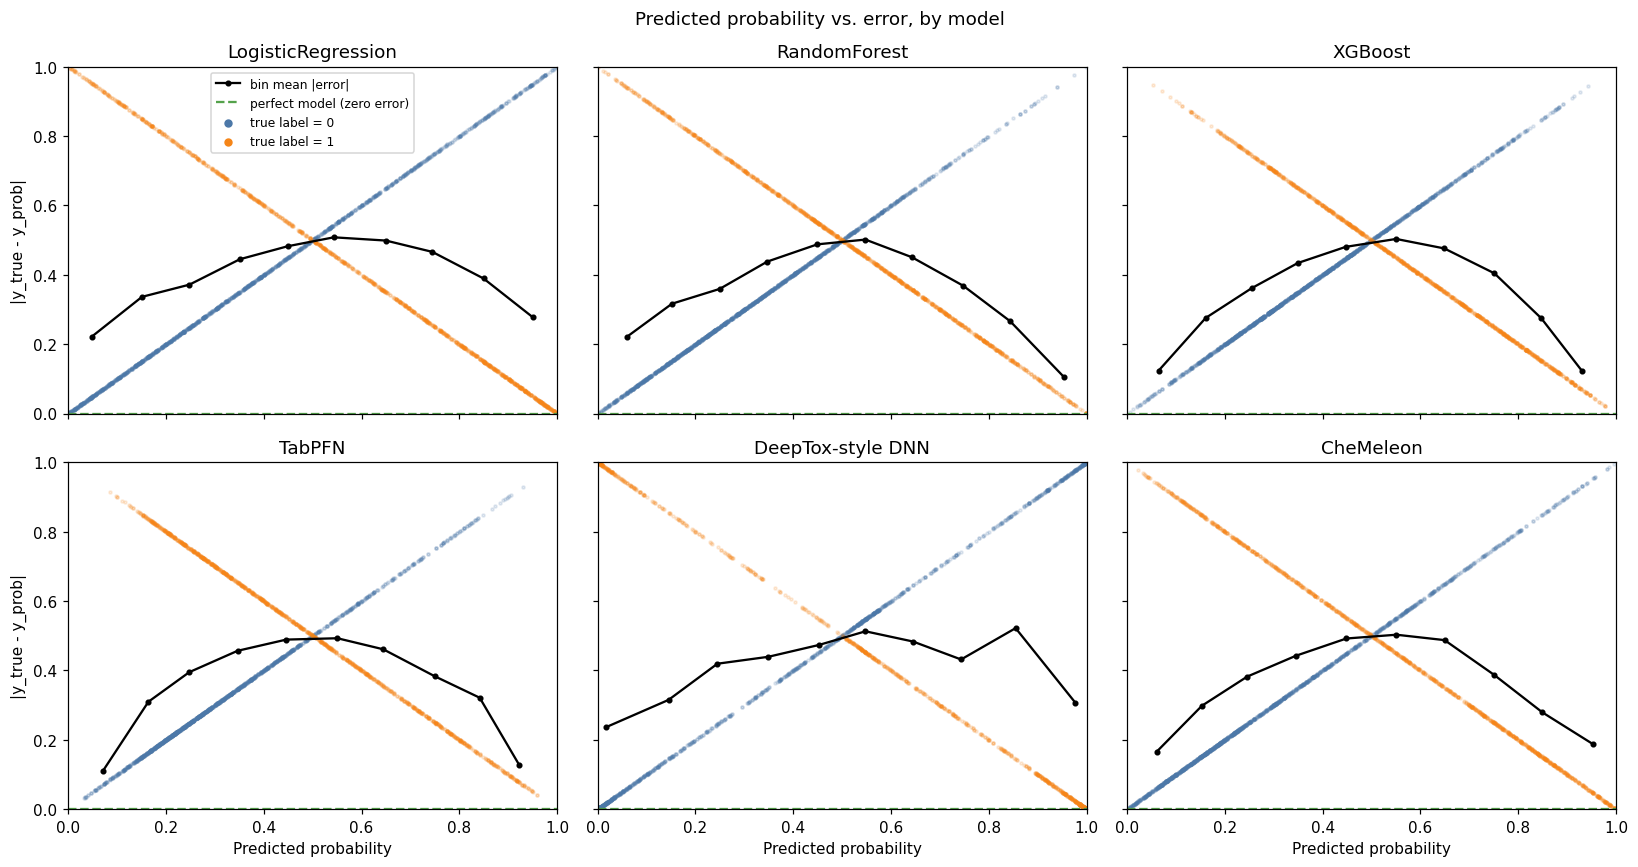

In [18]:
model_probs = {
    "LogisticRegression": y_prob_logreg,
    "RandomForest": y_prob_rf,
    "XGBoost": y_prob_xgb,
    "TabPFN": y_prob_tabpfn,
    "DeepTox-style DNN": y_prob_deeptox,
}
if os.path.exists(chemeleon_preds_path):
    model_probs["CheMeleon"] = y_prob_chemeleon

N_BINS = 10
bin_edges = np.linspace(0, 1, N_BINS + 1)
class_colors = {0: "#4C78A8", 1: "#F58518"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, (name, y_prob) in zip(axes.flat, model_probs.items()):
    y_prob = np.asarray(y_prob)
    abs_err = np.abs(y_test - y_prob)

    ax.axhline(0, color="#54A24B", ls="--", lw=1.5, label="perfect model (zero error)")

    for cls in (0, 1):
        mask = y_test == cls
        ax.scatter(y_prob[mask], abs_err[mask], s=4, alpha=0.15, color=class_colors[cls])

    bin_idx = np.clip(np.digitize(y_prob, bin_edges) - 1, 0, N_BINS - 1)
    occupied = [b for b in range(N_BINS) if (bin_idx == b).any()]
    bin_prob = [y_prob[bin_idx == b].mean() for b in occupied]
    bin_err = [abs_err[bin_idx == b].mean() for b in occupied]
    ax.plot(bin_prob, bin_err, color="black", lw=1.5, marker="o", markersize=3, label="bin mean |error|")

    ax.set_title(name)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

axes.flat[0].scatter([], [], s=20, color=class_colors[0], label="true label = 0")
axes.flat[0].scatter([], [], s=20, color=class_colors[1], label="true label = 1")
handles, labels = axes.flat[0].get_legend_handles_labels()
order = ["bin mean |error|", "perfect model (zero error)", "true label = 0", "true label = 1"]
by_label = dict(zip(labels, handles))
axes.flat[0].legend([by_label[l] for l in order], order, loc="upper center", fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel("Predicted probability")
for ax in axes[:, 0]:
    ax.set_ylabel("|y_true - y_prob|")
for ax in axes.flat[len(model_probs):]:
    ax.set_visible(False)

fig.suptitle("Predicted probability vs. error, by model")
plt.tight_layout()
plt.show()

## 15. Do errors cluster by scaffold / chemical class?

Using Bemis-Murcko generic scaffolds (the ring-system skeleton, via RDKit) as a proxy for "chemical class" — compounds sharing a scaffold are structurally related in a way `source`/`biological_context` don't capture. Two checks on the test set:

1. **Permutation test**: for each model, compare the actual variance of mean error *across scaffolds* (scaffolds with ≥5 test compounds) against a null distribution built by randomly reshuffling each model's per-compound errors across those same compounds many times. If the observed between-scaffold variance sits far above the null, errors are clustering by chemotype rather than scattering randomly.
2. **Heatmap**: mean error per model for the most common test-set scaffolds, to see which specific chemotypes are hardest (and whether that's consistent across models or model-specific).

In [19]:
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    scaffold_smiles = Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))
    return scaffold_smiles if scaffold_smiles else "(acyclic)"

test_smiles = meta_test["canonical_smiles"].values
scaffold_cache = {s: get_scaffold(s) for s in set(test_smiles)}
scaffolds = np.array([scaffold_cache[s] for s in test_smiles])

error_df = pd.DataFrame({"scaffold": scaffolds})
for name, y_prob in model_probs.items():
    error_df[name] = np.abs(y_test - np.asarray(y_prob))

scaffold_counts = pd.Series(scaffolds).value_counts()
print(f"{len(scaffold_counts)} distinct scaffolds across {len(scaffolds)} test compounds "
      f"({(scaffold_counts == 1).sum()} singletons)")

MIN_SCAFFOLD_SIZE = 5
common_scaffolds = scaffold_counts[scaffold_counts >= MIN_SCAFFOLD_SIZE].index
mask_common = np.isin(scaffolds, common_scaffolds)
print(f"{len(common_scaffolds)} scaffolds with >= {MIN_SCAFFOLD_SIZE} test compounds, "
      f"covering {mask_common.sum()}/{len(scaffolds)} test rows")

688 distinct scaffolds across 2825 test compounds (278 singletons)
51 scaffolds with >= 5 test compounds, covering 1746/2825 test rows


In [20]:
rng = np.random.default_rng(42)
N_PERM = 2000

group_ids = scaffolds[mask_common]
codes, uniques = pd.factorize(group_ids)
n_groups, n = len(uniques), len(codes)
indicator = np.zeros((n_groups, n), dtype=np.float32)
indicator[codes, np.arange(n)] = 1.0
counts = indicator.sum(axis=1)

scaffold_test_rows = []
for name in model_probs:
    errors = error_df.loc[mask_common, name].to_numpy()
    obs_var = ((indicator @ errors) / counts).var()

    perm = np.array([rng.permutation(errors) for _ in range(N_PERM)]).T  # (n, N_PERM)
    perm_means = (indicator @ perm) / counts[:, None]                    # (n_groups, N_PERM)
    perm_vars = perm_means.var(axis=0)

    z = (obs_var - perm_vars.mean()) / perm_vars.std()
    p = (perm_vars >= obs_var).mean()
    scaffold_test_rows.append({
        "model": name, "obs_var": obs_var, "null_mean_var": perm_vars.mean(),
        "z_score": z, "p_value": p,
    })

scaffold_test_df = pd.DataFrame(scaffold_test_rows)
scaffold_test_df

,model,obs_var,null_mean_var,z_score,p_value
0,LogisticRegression,0.015476,0.007961,4.476195,0.0005
1,RandomForest,0.011677,0.006713,3.503265,0.0010
2,XGBoost,0.008517,0.004166,5.011547,0.0005
3,TabPFN,0.010561,0.004974,5.110419,0.0000
4,DeepTox-style DNN,0.033316,0.014889,5.812557,0.0000
5,CheMeleon,0.012111,0.007671,2.678059,0.0125


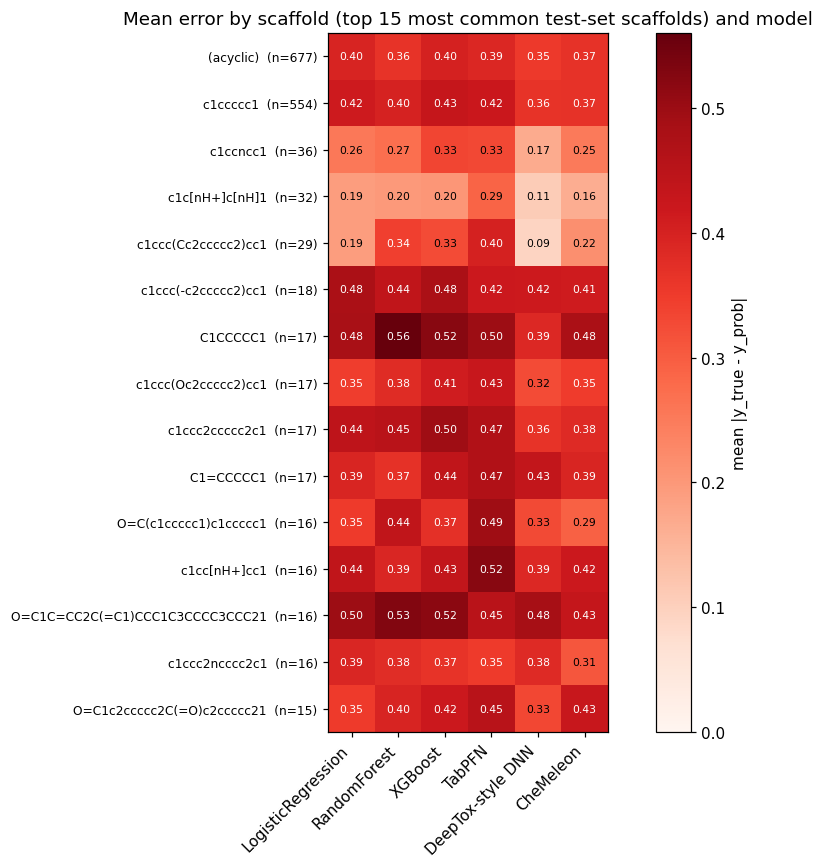

In [21]:
TOP_N = 15
top_scaffolds = scaffold_counts.loc[common_scaffolds].sort_values(ascending=False).head(TOP_N).index.tolist()
model_names = list(model_probs.keys())

heat = np.array([
    [error_df.loc[scaffolds == scaf, name].mean() for name in model_names]
    for scaf in top_scaffolds
])
row_labels = [f"{s[:35]}{'…' if len(s) > 35 else ''}  (n={scaffold_counts[s]})" for s in top_scaffolds]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(heat, cmap="Reds", vmin=0, vmax=heat.max())
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=45, ha="right")
ax.set_yticks(range(len(top_scaffolds)))
ax.set_yticklabels(row_labels, fontsize=8)
for i in range(len(top_scaffolds)):
    for j in range(len(model_names)):
        ax.text(j, i, f"{heat[i, j]:.2f}", ha="center", va="center", fontsize=7,
                 color="white" if heat[i, j] > heat.max() * 0.6 else "black")
fig.colorbar(im, ax=ax, label="mean |y_true - y_prob|")
ax.set_title(f"Mean error by scaffold (top {TOP_N} most common test-set scaffolds) and model")
plt.tight_layout()
plt.show()

### Scaffold-clustering takeaways

- **Errors cluster by scaffold for every model, not just noise**: the permutation test rejects "errors are scaffold-independent" at p < 0.02 for all six models (p < 0.001 for four of them). DeepTox-style DNN clusters the most (z=5.8), CheMeleon the least (z=2.7) — consistent with CheMeleon's graph representation generalizing better across chemotypes than fingerprint-based models.
- Of 688 distinct test-set scaffolds, only 51 have ≥5 compounds (covering 1,746/2,825 rows) — most chemotypes are singletons or near-singletons, so per-scaffold analysis is only reliable for these 51.
- **Consistently easy** chemotypes: protonated-imidazole/pyridinium rings (`c1c[nH+]c[nH]1`, mean error 0.11–0.29) and the biphenyl-ether scaffold (`c1ccc(Oc2ccccc2)cc1`) sit well below the ~0.4 overall baseline across every model.
- **Consistently hard** chemotypes: plain cyclohexane (`C1CCCCC1`, n=17) and the steroid-like fused-ring scaffold (`O=C1C=CC2C(=C1)CCC3CCCC3CCC21`, n=16) both sit at 0.4–0.56 error across all six models — these are scaffolds none of the models handle well, not a single-model quirk.
- The plain benzene ring (`c1ccccc1`, n=554) and acyclic compounds (n=677) — the two largest buckets — sit close to the ~0.4 overall mean error, so the aggregate metrics in earlier sections are dominated by these generic, moderately-hard cases rather than by the easy or hard extremes.

### Verifying the DeepTox-style DNN scaffold effect

The permutation test above is a custom implementation — worth cross-checking with an independent, well-known test and by actually looking at the numbers behind it, rather than trusting one z-score:

1. **Kruskal-Wallis H-test** (`scipy.stats`, non-parametric one-way ANOVA) on the same scaffold groups, for every model — an off-the-shelf test that should agree with the permutation-test ranking if the effect is real.
2. **Per-scaffold error plot for DeepTox specifically** — mean error ± SEM for every scaffold with ≥5 test compounds, sorted, against the overall mean error line. Real clustering should look like scaffolds sitting well outside their own error bars on both sides of that line, not just noisy jitter around it.
3. **Named hardest/easiest scaffolds** for DeepTox, to sanity-check the numbers against actual chemical structures.

In [22]:
from scipy import stats

kw_rows = []
for name in model_probs:
    errors = error_df.loc[mask_common, name].to_numpy()
    groups = [errors[group_ids == g] for g in uniques]
    h, p = stats.kruskal(*groups)
    kw_rows.append({"model": name, "kruskal_H": h, "kruskal_p": p})

kw_df = pd.DataFrame(kw_rows).merge(
    scaffold_test_df[["model", "z_score", "p_value"]].rename(columns={"p_value": "permutation_p"}),
    on="model",
)
kw_df

,model,kruskal_H,kruskal_p,z_score,permutation_p
0,LogisticRegression,153.854921,1.670924e-12,4.476195,0.0005
1,RandomForest,152.805850,2.402877e-12,3.503265,0.0010
2,XGBoost,178.075735,2.900556e-16,5.011547,0.0005
3,TabPFN,165.294859,2.975570e-14,5.110419,0.0000
4,DeepTox-style DNN,174.247560,1.176630e-15,5.812557,0.0000
5,CheMeleon,152.789548,2.416459e-12,2.678059,0.0125


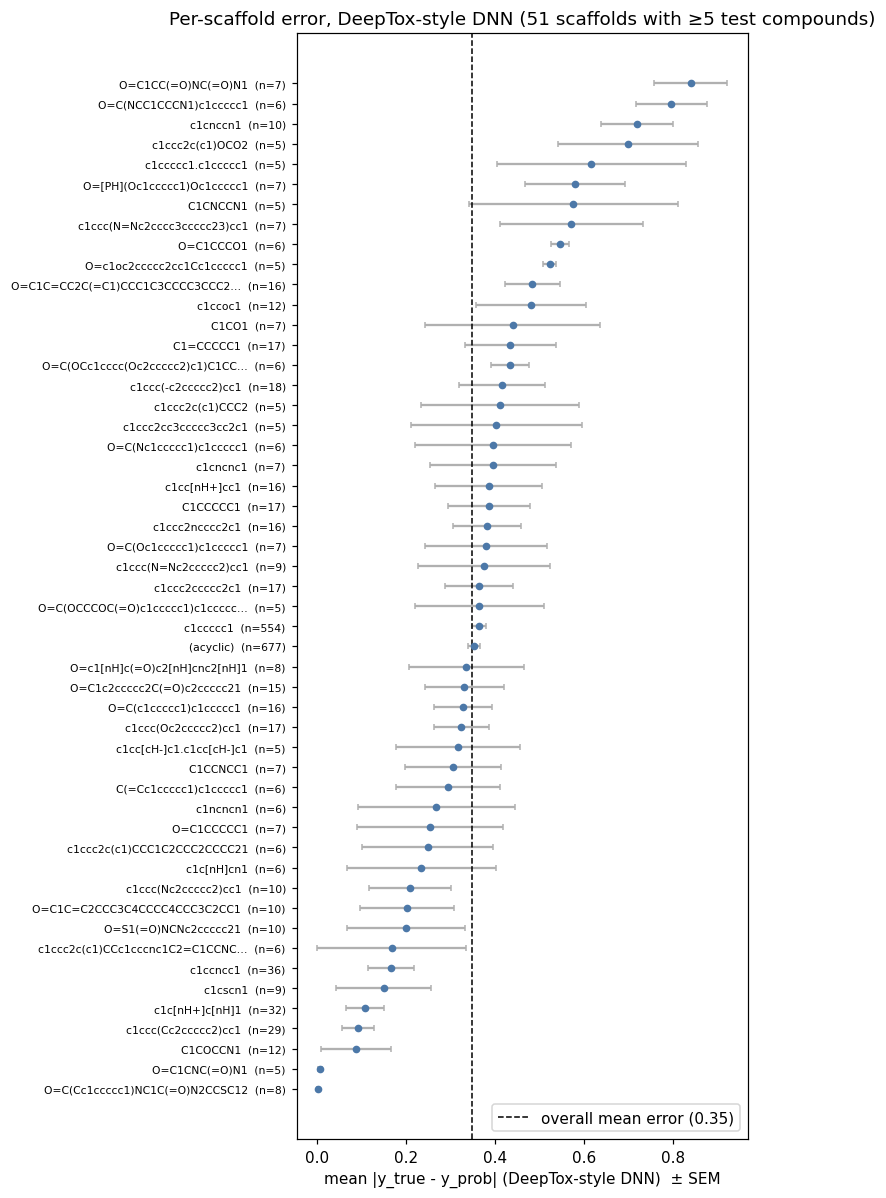

In [23]:
DEEPTOX_NAME = "DeepTox-style DNN"

scaffold_stats = (
    error_df.loc[mask_common]
    .groupby("scaffold")[DEEPTOX_NAME]
    .agg(["mean", "std", "count"])
    .loc[common_scaffolds]
    .sort_values("mean")
)
overall_mean = error_df.loc[mask_common, DEEPTOX_NAME].mean()

fig, ax = plt.subplots(figsize=(7, 11))
y_pos = np.arange(len(scaffold_stats))
ax.errorbar(
    scaffold_stats["mean"], y_pos,
    xerr=scaffold_stats["std"] / np.sqrt(scaffold_stats["count"]),
    fmt="o", markersize=4, color="#4C78A8", ecolor="#B0B0B0", capsize=2,
)
ax.axvline(overall_mean, color="black", ls="--", lw=1, label=f"overall mean error ({overall_mean:.2f})")
ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f"{s[:30]}{'…' if len(s) > 30 else ''}  (n={n})" for s, n in zip(scaffold_stats.index, scaffold_stats["count"])],
    fontsize=7,
)
ax.set_xlabel(f"mean |y_true - y_prob| ({DEEPTOX_NAME})  ± SEM")
ax.set_title(f"Per-scaffold error, {DEEPTOX_NAME} ({len(scaffold_stats)} scaffolds with ≥{MIN_SCAFFOLD_SIZE} test compounds)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [24]:
print(f"5 hardest scaffolds for {DEEPTOX_NAME}:")
print(scaffold_stats.tail(5)[::-1].to_string())
print(f"\n5 easiest scaffolds for {DEEPTOX_NAME}:")
print(scaffold_stats.head(5).to_string())

5 hardest scaffolds for DeepTox-style DNN:
                            mean       std  count
O=C1CC(=O)NC(=O)N1      0.838864  0.219139      7
O=C(NCC1CCCN1)c1ccccc1  0.795972  0.195969      6
c1cnccn1                0.718787  0.255241     10
c1ccc2c(c1)OCO2         0.698642  0.350016      5
c1ccccc1.c1ccccc1       0.616493  0.476482      5

5 easiest scaffolds for DeepTox-style DNN:
                                    mean       std  count
O=C(Cc1ccccc1)NC1C(=O)N2CCSC12  0.001923  0.003528      8
O=C1CNC(=O)N1                   0.007701  0.009650      5
C1COCCN1                        0.087708  0.273655     12
c1ccc(Cc2ccccc2)cc1             0.092580  0.191081     29
c1c[nH+]c[nH]1                  0.108637  0.245071     32


# Part 2: Scaffold split

Section 7's `StratifiedGroupKFold` split groups by `cid` (compound identity) — it guarantees the exact same molecule never appears in both train and test, but says nothing about *structurally related* molecules. A follow-up check found that **79.4% of test rows share a Bemis-Murcko scaffold with something in train** (only 47.5% of distinct test scaffolds are genuinely novel) — so the Part 1 metrics mostly measure interpolation within known chemotypes, not generalization to new ones.

This section repeats the exact same pipeline — same featurization, same six models, same diagnostics — but replaces the split's grouping key with **scaffold** instead of `cid`. Every compound sharing a scaffold now lands entirely in train or entirely in test, so no scaffold leaks across the split. This is a strictly harder, more realistic test of generalization, and the gap between Part 1 and Part 2 metrics is itself the diagnostic of interest.

## 16. Scaffold split

In [25]:
# Scaffold for every compound in the modeling set (not just the Part 1 test set this time)
all_smiles = model_df["canonical_smiles"].unique()
full_scaffold_cache = {s: get_scaffold(s) for s in all_smiles}
model_df["_scaffold"] = model_df["canonical_smiles"].map(full_scaffold_cache)

print(f"{model_df['_scaffold'].nunique()} distinct scaffolds across {len(model_df)} modeling rows "
      f"({(model_df['_scaffold'].value_counts() == 1).sum()} singletons)")

2371 distinct scaffolds across 14105 modeling rows (787 singletons)


### A properly size-aware scaffold split

`StratifiedGroupKFold` works well when grouping by `cid` (every group has at most 2 rows), but scaffold group sizes are extremely skewed — a handful of scaffolds (plain benzene ring, the acyclic bucket, ...) contain hundreds of compounds each, while most scaffolds are singletons. Handing that as the `groups` argument to a k-fold splitter built for roughly-even group sizes produces a degenerate split (confirmed empirically: it put 97.7% of rows in train and only 322 in test, vs. the intended ~80/20).

Instead, use a greedy size-aware allocator (the same idea as DeepChem's `ScaffoldSplitter`): shuffle scaffold groups, sort them largest-first, and greedily add each whole group to train until adding the next one would exceed the target train fraction — everything left over goes to test. This packs train tightly to the target size while keeping every scaffold's compounds entirely on one side of the split.

In [26]:
def greedy_scaffold_split(scaffold_values, frac_train=0.8, seed=42):
    scaffold_to_indices = {}
    for idx, scaf in enumerate(scaffold_values):
        scaffold_to_indices.setdefault(scaf, []).append(idx)
    scaffold_sets = list(scaffold_to_indices.values())

    rng = np.random.default_rng(seed)
    order = rng.permutation(len(scaffold_sets))
    scaffold_sets = [scaffold_sets[i] for i in order]
    scaffold_sets.sort(key=len, reverse=True)

    n_total = len(scaffold_values)
    train_cutoff = frac_train * n_total

    train_idx, test_idx = [], []
    for s in scaffold_sets:
        if len(train_idx) + len(s) <= train_cutoff:
            train_idx.extend(s)
        else:
            test_idx.extend(s)
    return np.array(sorted(train_idx)), np.array(sorted(test_idx))

In [27]:
scaffold_groups = model_df["_scaffold"].values
train_idx_s, test_idx_s = greedy_scaffold_split(scaffold_groups, frac_train=0.8, seed=42)

X_train_s, X_test_s = X[train_idx_s], X[test_idx_s]
y_train_s, y_test_s = y[train_idx_s], y[test_idx_s]
meta_train_s, meta_test_s = model_df.iloc[train_idx_s], model_df.iloc[test_idx_s]

assert set(meta_train_s["_scaffold"]) & set(meta_test_s["_scaffold"]) == set(), "scaffold leakage between train/test!"

print(f"Train: {len(X_train_s)} rows ({y_train_s.mean():.1%} active), {meta_train_s['_scaffold'].nunique()} unique scaffolds")
print(f"Test:  {len(X_test_s)} rows ({y_test_s.mean():.1%} active), {meta_test_s['_scaffold'].nunique()} unique scaffolds")
print("\nTrain source breakdown:\n", meta_train_s["source"].value_counts())
print("\nTest source breakdown:\n", meta_test_s["source"].value_counts())

results_scaffold = []

def make_evaluator(results_list):
    def _evaluate(name, y_true, y_prob, meta):
        y_pred = (y_prob >= 0.5).astype(int)
        row = {
            "model": name,
            "roc_auc": roc_auc_score(y_true, y_prob),
            "pr_auc": average_precision_score(y_true, y_prob),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred),
        }
        for src in meta["source"].unique():
            mask = (meta["source"] == src).values
            if mask.sum() > 0 and len(np.unique(y_true[mask])) > 1:
                row[f"roc_auc_{src}"] = roc_auc_score(y_true[mask], y_prob[mask])
        results_list.append(row)
        print(f"{name}: ROC-AUC={row['roc_auc']:.3f}  PR-AUC={row['pr_auc']:.3f}  "
              f"balanced_acc={row['balanced_accuracy']:.3f}  F1={row['f1']:.3f}")
        for src in meta["source"].unique():
            k = f"roc_auc_{src}"
            if k in row:
                print(f"    {src} ROC-AUC: {row[k]:.3f}")
        return row
    return _evaluate

evaluate_scaffold = make_evaluator(results_scaffold)

Train: 11284 rows (37.6% active), 567 unique scaffolds
Test:  2821 rows (51.5% active), 1804 unique scaffolds

Train source breakdown:
 source
ToxCast    6152
Tox21      5132
Name: count, dtype: int64

Test source breakdown:
 source
ToxCast    1653
Tox21      1168
Name: count, dtype: int64


## 17. Model 1 — Logistic Regression (scaffold split)

In [28]:
logreg_s = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
logreg_s.fit(X_train_s, y_train_s)
y_prob_logreg_s = logreg_s.predict_proba(X_test_s)[:, 1]
_ = evaluate_scaffold("LogisticRegression", y_test_s, y_prob_logreg_s, meta_test_s)

LogisticRegression: ROC-AUC=0.666  PR-AUC=0.674  balanced_acc=0.617  F1=0.611
    Tox21 ROC-AUC: 0.678
    ToxCast ROC-AUC: 0.673


## 18. Model 2 — Random Forest (scaffold split)

In [29]:
rf_s = RandomForestClassifier(
    n_estimators=500, max_depth=None, class_weight="balanced_subsample",
    n_jobs=-1, random_state=42,
)
rf_s.fit(X_train_s, y_train_s)
y_prob_rf_s = rf_s.predict_proba(X_test_s)[:, 1]
_ = evaluate_scaffold("RandomForest", y_test_s, y_prob_rf_s, meta_test_s)

RandomForest: ROC-AUC=0.727  PR-AUC=0.720  balanced_acc=0.649  F1=0.582
    Tox21 ROC-AUC: 0.737
    ToxCast ROC-AUC: 0.738


## 19. Model 3 — XGBoost (scaffold split)

In [30]:
scale_pos_weight_s = (y_train_s == 0).sum() / (y_train_s == 1).sum()
xgb_clf_s = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_s,
    eval_metric="logloss", n_jobs=-1, random_state=42,
)
xgb_clf_s.fit(X_train_s, y_train_s)
y_prob_xgb_s = xgb_clf_s.predict_proba(X_test_s)[:, 1]
_ = evaluate_scaffold("XGBoost", y_test_s, y_prob_xgb_s, meta_test_s)

XGBoost: ROC-AUC=0.716  PR-AUC=0.715  balanced_acc=0.645  F1=0.636
    Tox21 ROC-AUC: 0.733
    ToxCast ROC-AUC: 0.722


## 20. Model 4 — TabPFN (scaffold split)

In [31]:
pca_s = PCA(n_components=TABPFN_N_COMPONENTS, random_state=42)
X_train_pca_s = pca_s.fit_transform(X_train_s)
X_test_pca_s = pca_s.transform(X_test_s)
print(f"PCA explained variance ratio (sum of {TABPFN_N_COMPONENTS} components): {pca_s.explained_variance_ratio_.sum():.3f}")

if len(X_train_pca_s) > TABPFN_MAX_TRAIN:
    X_train_tab_s, _, y_train_tab_s, _ = train_test_split(
        X_train_pca_s, y_train_s, train_size=TABPFN_MAX_TRAIN, stratify=y_train_s, random_state=42,
    )
else:
    X_train_tab_s, y_train_tab_s = X_train_pca_s, y_train_s
print(f"TabPFN training subsample: {len(X_train_tab_s)} rows ({y_train_tab_s.mean():.1%} active)")

tabpfn_clf_s = TabPFNClassifier(device="auto", random_state=42, ignore_pretraining_limits=True)
tabpfn_clf_s.fit(X_train_tab_s, y_train_tab_s)
y_prob_tabpfn_s = tabpfn_clf_s.predict_proba(X_test_pca_s)[:, 1]
_ = evaluate_scaffold("TabPFN", y_test_s, y_prob_tabpfn_s, meta_test_s)

PCA explained variance ratio (sum of 100 components): 0.572
TabPFN training subsample: 3000 rows (37.6% active)
TabPFN: ROC-AUC=0.706  PR-AUC=0.711  balanced_acc=0.622  F1=0.519
    Tox21 ROC-AUC: 0.709
    ToxCast ROC-AUC: 0.720


## 21. Model 5 — CheMeleon (scaffold split)

Unlike Part 1, this run actually executes `chemprop train`/`chemprop predict` inline (GPU is available, so a 30-epoch fine-tune is a few minutes, not the CPU-bound "leave it for later" situation in section 12) — same CLI invocation, new scaffold-grouped train/val/test CSVs.

In [32]:
CHEMPROP_DIR_S = f"{REPO_ROOT}/notebooks/_chemprop_run_scaffold"
os.makedirs(CHEMPROP_DIR_S, exist_ok=True)

# Carve a val split out of the training compounds only, grouped by scaffold this time.
tr_sub_idx_s, val_idx_s = greedy_scaffold_split(
    meta_train_s["_scaffold"].values, frac_train=0.9, seed=42,
)

train_csv_s = meta_train_s.iloc[tr_sub_idx_s][["canonical_smiles", "cytotoxic_label"]]
val_csv_s = meta_train_s.iloc[val_idx_s][["canonical_smiles", "cytotoxic_label"]]
test_csv_s = meta_test_s[["canonical_smiles", "cytotoxic_label"]]

train_csv_s.to_csv(f"{CHEMPROP_DIR_S}/train.csv", index=False)
val_csv_s.to_csv(f"{CHEMPROP_DIR_S}/val.csv", index=False)
test_csv_s.to_csv(f"{CHEMPROP_DIR_S}/test.csv", index=False)
print(f"train={len(train_csv_s)}  val={len(val_csv_s)}  test={len(test_csv_s)}")

train=10155  val=1129  test=2821


In [33]:
import subprocess

CHEMPROP_BIN = "/nethome/akarimi/miniconda3/envs/influnc/bin/chemprop"
chemeleon_preds_path_s = f"{CHEMPROP_DIR_S}/chemeleon_preds.csv"

if not os.path.exists(chemeleon_preds_path_s):
    train_cmd = [
        CHEMPROP_BIN, "train",
        "-i", "train.csv", "val.csv",
        "-s", "canonical_smiles", "--target-columns", "cytotoxic_label", "--task-type", "classification",
        "--from-foundation", "CHEMELEON",
        "--epochs", "30", "--split-sizes", "0.9", "0.1", "0.0",
        "-o", "chemeleon_run",
    ]
    result = subprocess.run(train_cmd, cwd=CHEMPROP_DIR_S, capture_output=True, text=True)
    print(result.stdout[-3000:])
    if result.returncode != 0:
        print(result.stderr[-3000:])
    result.check_returncode()

    predict_cmd = [
        CHEMPROP_BIN, "predict",
        "-i", "test.csv", "-s", "canonical_smiles",
        "--model-paths", "chemeleon_run/model_0/best.pt",
        "-o", "chemeleon_preds.csv",
    ]
    result2 = subprocess.run(predict_cmd, cwd=CHEMPROP_DIR_S, capture_output=True, text=True)
    print(result2.stdout[-2000:])
    if result2.returncode != 0:
        print(result2.stderr[-2000:])
    result2.check_returncode()
else:
    print("CheMeleon predictions already exist for the scaffold split, skipping retraining.")

CheMeleon predictions already exist for the scaffold split, skipping retraining.


In [34]:
chemeleon_out_s = pd.read_csv(chemeleon_preds_path_s)
assert len(chemeleon_out_s) == len(meta_test_s), "row count mismatch -- did test.csv change?"
y_prob_chemeleon_s = chemeleon_out_s["cytotoxic_label"].values
_ = evaluate_scaffold("CheMeleon", y_test_s, y_prob_chemeleon_s, meta_test_s)

CheMeleon: ROC-AUC=0.750  PR-AUC=0.757  balanced_acc=0.696  F1=0.678
    Tox21 ROC-AUC: 0.765
    ToxCast ROC-AUC: 0.766


## 22. Model 6 — DeepTox-style DNN (scaffold split)

In [35]:
desc_train_raw_s = np.stack([desc_cache[s] for s in meta_train_s["canonical_smiles"]])
desc_test_raw_s = np.stack([desc_cache[s] for s in meta_test_s["canonical_smiles"]])

desc_scaler_s = StandardScaler()
desc_train_s = desc_scaler_s.fit_transform(desc_train_raw_s)
desc_test_s = desc_scaler_s.transform(desc_test_raw_s)

X_train_dt_s = np.concatenate([X_train_s, desc_train_s], axis=1).astype(np.float32)
X_test_dt_s = np.concatenate([X_test_s, desc_test_s], axis=1).astype(np.float32)
print(f"DeepTox feature matrix: train={X_train_dt_s.shape}  test={X_test_dt_s.shape}")

torch.manual_seed(42)

model_s = DeepToxDNN(in_dim=X_train_dt_s.shape[1]).to(device)
pos_weight_s = torch.tensor([(y_train_s == 0).sum() / (y_train_s == 1).sum()], dtype=torch.float32, device=device)
criterion_s = nn.BCEWithLogitsLoss(pos_weight=pos_weight_s)
optimizer_s = torch.optim.Adam(model_s.parameters(), lr=1e-3, weight_decay=1e-5)

Xt_s = torch.tensor(X_train_dt_s, device=device)
yt_s = torch.tensor(y_train_s, dtype=torch.float32, device=device)
Xv_s = torch.tensor(X_test_dt_s, device=device)

n_s = len(Xt_s)
for epoch in range(N_EPOCHS):
    model_s.train()
    perm = torch.randperm(n_s)
    epoch_loss = 0.0
    for i in range(0, n_s, BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        optimizer_s.zero_grad()
        logits = model_s(Xt_s[idx])
        loss = criterion_s(logits, yt_s[idx])
        loss.backward()
        optimizer_s.step()
        epoch_loss += loss.item() * len(idx)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"epoch {epoch+1}/{N_EPOCHS}  loss={epoch_loss/n_s:.4f}")

model_s.eval()
with torch.no_grad():
    y_prob_deeptox_s = torch.sigmoid(model_s(Xv_s)).cpu().numpy()
_ = evaluate_scaffold("DeepTox-style DNN", y_test_s, y_prob_deeptox_s, meta_test_s)

DeepTox feature matrix: train=(11284, 2058)  test=(2821, 2058)
epoch 1/30  loss=0.7692
epoch 5/30  loss=0.5453
epoch 10/30  loss=0.4311
epoch 15/30  loss=0.3805
epoch 20/30  loss=0.3546
epoch 25/30  loss=0.3224
epoch 30/30  loss=0.3119
DeepTox-style DNN: ROC-AUC=0.702  PR-AUC=0.716  balanced_acc=0.647  F1=0.675
    Tox21 ROC-AUC: 0.722
    ToxCast ROC-AUC: 0.710


## 23. Predicted probability vs. error, by model (scaffold split)

Same diagnostic as section 14, on the scaffold-split test set.

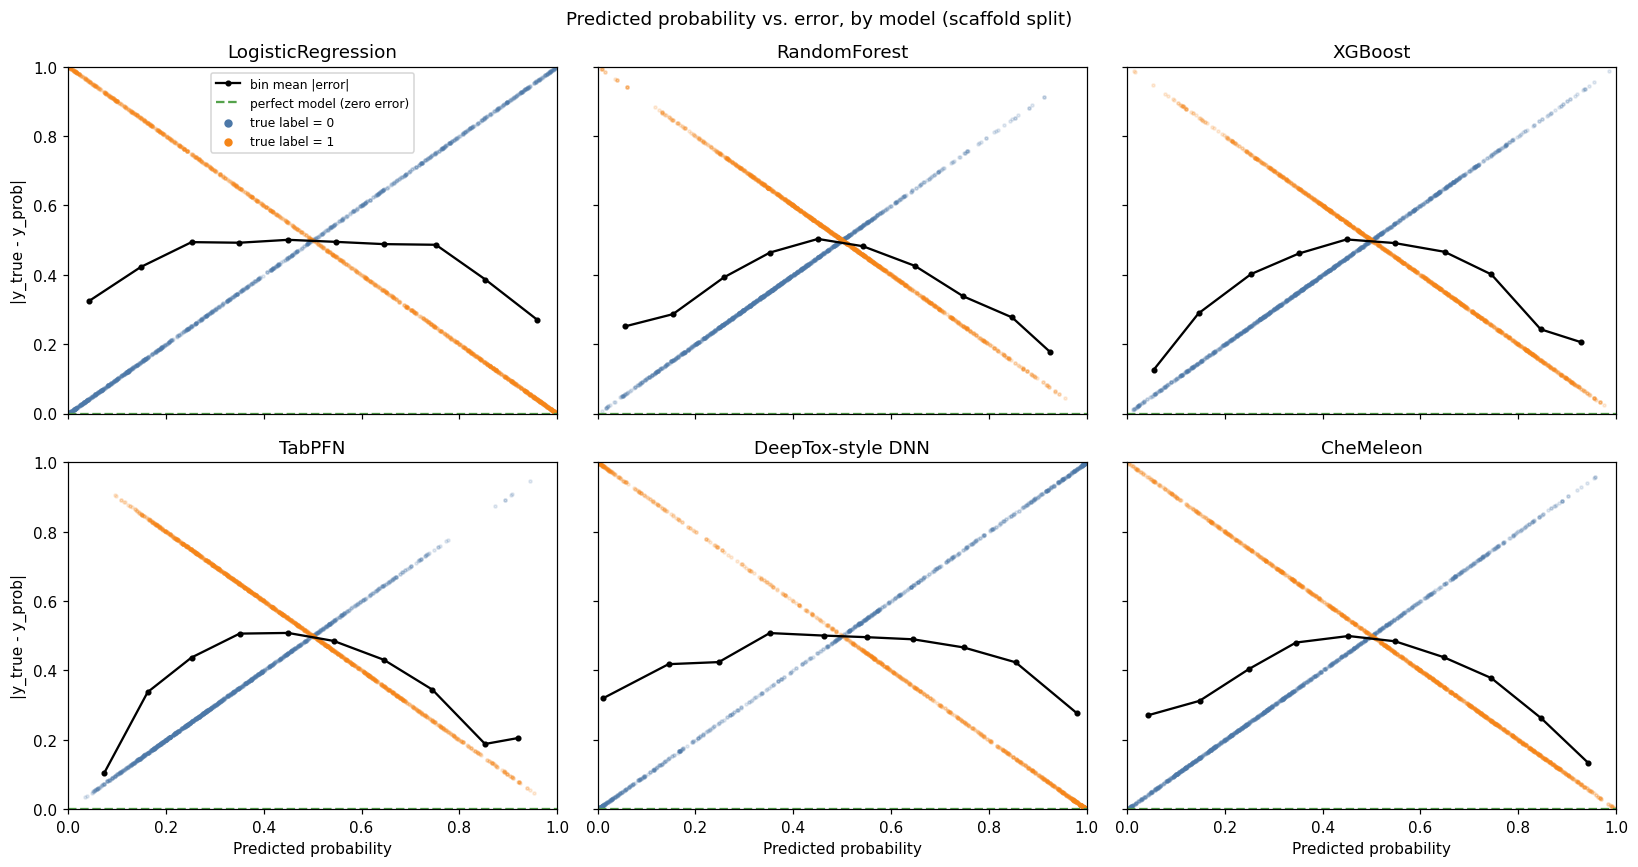

In [36]:
model_probs_s = {
    "LogisticRegression": y_prob_logreg_s,
    "RandomForest": y_prob_rf_s,
    "XGBoost": y_prob_xgb_s,
    "TabPFN": y_prob_tabpfn_s,
    "DeepTox-style DNN": y_prob_deeptox_s,
}
if os.path.exists(chemeleon_preds_path_s):
    model_probs_s["CheMeleon"] = y_prob_chemeleon_s

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, (name, y_prob) in zip(axes.flat, model_probs_s.items()):
    y_prob = np.asarray(y_prob)
    abs_err = np.abs(y_test_s - y_prob)

    ax.axhline(0, color="#54A24B", ls="--", lw=1.5, label="perfect model (zero error)")

    for cls in (0, 1):
        mask = y_test_s == cls
        ax.scatter(y_prob[mask], abs_err[mask], s=4, alpha=0.15, color=class_colors[cls])

    bin_idx = np.clip(np.digitize(y_prob, bin_edges) - 1, 0, N_BINS - 1)
    occupied = [b for b in range(N_BINS) if (bin_idx == b).any()]
    bin_prob = [y_prob[bin_idx == b].mean() for b in occupied]
    bin_err = [abs_err[bin_idx == b].mean() for b in occupied]
    ax.plot(bin_prob, bin_err, color="black", lw=1.5, marker="o", markersize=3, label="bin mean |error|")

    ax.set_title(name)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

axes.flat[0].scatter([], [], s=20, color=class_colors[0], label="true label = 0")
axes.flat[0].scatter([], [], s=20, color=class_colors[1], label="true label = 1")
handles, labels = axes.flat[0].get_legend_handles_labels()
order = ["bin mean |error|", "perfect model (zero error)", "true label = 0", "true label = 1"]
by_label = dict(zip(labels, handles))
axes.flat[0].legend([by_label[l] for l in order], order, loc="upper center", fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel("Predicted probability")
for ax in axes[:, 0]:
    ax.set_ylabel("|y_true - y_prob|")
for ax in axes.flat[len(model_probs_s):]:
    ax.set_visible(False)

fig.suptitle("Predicted probability vs. error, by model (scaffold split)")
plt.tight_layout()
plt.show()

## 24. Do errors cluster by scaffold? (scaffold split)

Every test scaffold here is entirely unseen in training by construction. A side effect of the greedy allocator (section 16): it fills train with the biggest scaffold clusters first, so almost every test scaffold ends up tiny — checked empirically, the test set has 787 singleton scaffolds and 1,017 exact pairs (max scaffold size in test is **2**) out of 1,804 distinct scaffolds. Section 15's ≥5-member threshold has nothing to test on here, so this section lowers it to ≥2 (scaffolds that happen to appear as an exact pair in the held-out set). That has far less statistical power than Part 1's 51 scaffolds (up to hundreds of members each) — treat this result as suggestive, not confirmatory. No "most common scaffold" heatmap this time either: with everything tied at 2 members, "most common" isn't a meaningful ranking, so this looks at the pairs whose average error deviates most from the overall mean instead.

In [37]:
MIN_SCAFFOLD_SIZE_S = 2

scaffolds_s = meta_test_s["_scaffold"].values

error_df_s = pd.DataFrame({"scaffold": scaffolds_s})
for name, y_prob in model_probs_s.items():
    error_df_s[name] = np.abs(y_test_s - np.asarray(y_prob))

scaffold_counts_s = pd.Series(scaffolds_s).value_counts()
print(f"{len(scaffold_counts_s)} distinct scaffolds across {len(scaffolds_s)} test compounds "
      f"({(scaffold_counts_s == 1).sum()} singletons)")

common_scaffolds_s = scaffold_counts_s[scaffold_counts_s >= MIN_SCAFFOLD_SIZE_S].index
mask_common_s = np.isin(scaffolds_s, common_scaffolds_s)
print(f"{len(common_scaffolds_s)} scaffolds with >= {MIN_SCAFFOLD_SIZE_S} test compounds, "
      f"covering {mask_common_s.sum()}/{len(scaffolds_s)} test rows")

if len(common_scaffolds_s) == 0:
    print("No repeated scaffolds in this test set -- skipping the permutation test.")
    scaffold_test_df_s = pd.DataFrame(columns=["model", "obs_var", "null_mean_var", "z_score", "p_value"])
else:
    group_ids_s = scaffolds_s[mask_common_s]
    codes_s, uniques_s = pd.factorize(group_ids_s)
    n_groups_s, n_s2 = len(uniques_s), len(codes_s)
    indicator_s = np.zeros((n_groups_s, n_s2), dtype=np.float32)
    indicator_s[codes_s, np.arange(n_s2)] = 1.0
    counts_s = indicator_s.sum(axis=1)

    scaffold_test_rows_s = []
    for name in model_probs_s:
        errors = error_df_s.loc[mask_common_s, name].to_numpy()
        obs_var = ((indicator_s @ errors) / counts_s).var()

        perm = np.array([rng.permutation(errors) for _ in range(N_PERM)]).T
        perm_means = (indicator_s @ perm) / counts_s[:, None]
        perm_vars = perm_means.var(axis=0)

        z = (obs_var - perm_vars.mean()) / perm_vars.std()
        p = (perm_vars >= obs_var).mean()
        scaffold_test_rows_s.append({
            "model": name, "obs_var": obs_var, "null_mean_var": perm_vars.mean(),
            "z_score": z, "p_value": p,
        })

    scaffold_test_df_s = pd.DataFrame(scaffold_test_rows_s)

scaffold_test_df_s

1804 distinct scaffolds across 2821 test compounds (787 singletons)
1017 scaffolds with >= 2 test compounds, covering 2034/2821 test rows


,model,obs_var,null_mean_var,z_score,p_value
0,LogisticRegression,0.075955,0.051572,15.104325,0.0
1,RandomForest,0.024417,0.015660,17.996370,0.0
2,XGBoost,0.028974,0.019479,15.555113,0.0
3,TabPFN,0.032107,0.020898,17.670456,0.0
4,DeepTox-style DNN,0.101179,0.070548,14.080454,0.0
5,CheMeleon,0.043867,0.029217,16.211058,0.0


In [38]:
if len(common_scaffolds_s) == 0:
    print("No repeated scaffolds to inspect.")
else:
    model_cols_s = list(model_probs_s.keys())
    pair_means = error_df_s.loc[mask_common_s].groupby("scaffold")[model_cols_s].mean()
    pair_means["n"] = error_df_s.loc[mask_common_s].groupby("scaffold").size()
    overall_mean_s = error_df_s.loc[mask_common_s, model_cols_s].mean()

    pair_means["avg_dist_from_mean"] = (pair_means[model_cols_s] - overall_mean_s).abs().mean(axis=1)
    extreme_pairs = pair_means.sort_values("avg_dist_from_mean", ascending=False).head(5)

    print(f"{len(pair_means)} scaffold-pairs total in the test set. "
          f"The 5 whose average error across models deviates most from the overall mean:")
    print(extreme_pairs[model_cols_s].round(2).to_string())
    print("\noverall mean error per model:")
    print(overall_mean_s.round(2).to_string())

1017 scaffold-pairs total in the test set. The 5 whose average error across models deviates most from the overall mean:
                           LogisticRegression  RandomForest  XGBoost  TabPFN  DeepTox-style DNN  CheMeleon
scaffold                                                                                                  
O=C1CCCCCCCCCCCCCCCO1                    0.86          0.99     0.89    0.85               0.99       0.92
O=C1CCCCCCCCCCOCCCCO1                    0.83          0.99     0.89    0.83               1.00       0.91
O=C1CCCCCCCCCCC(=O)OCCO1                 0.92          0.94     0.88    0.83               0.92       0.89
O=C1CCCCCCCCCCCC(=O)OCCO1                0.92          0.94     0.88    0.83               0.89       0.90
c1ccc(SCSc2ccccc2)cc1                    0.97          0.91     0.94    0.72               1.00       0.81

overall mean error per model:
LogisticRegression    0.40
RandomForest          0.43
XGBoost               0.42
TabPFN             

## 25. Random split vs. scaffold split — the generalization gap

The actual point of Part 2: how much do the Part 1 (`cid`-grouped, scaffold-leaky) numbers overstate real-world generalization, model by model?

                    roc_auc_cid_split  roc_auc_scaffold_split  roc_auc_drop
model                                                                      
LogisticRegression              0.709                   0.666         0.043
DeepTox-style DNN               0.731                   0.702         0.029
XGBoost                         0.741                   0.716         0.025
CheMeleon                       0.766                   0.750         0.016
RandomForest                    0.740                   0.727         0.013
TabPFN                          0.711                   0.706         0.005


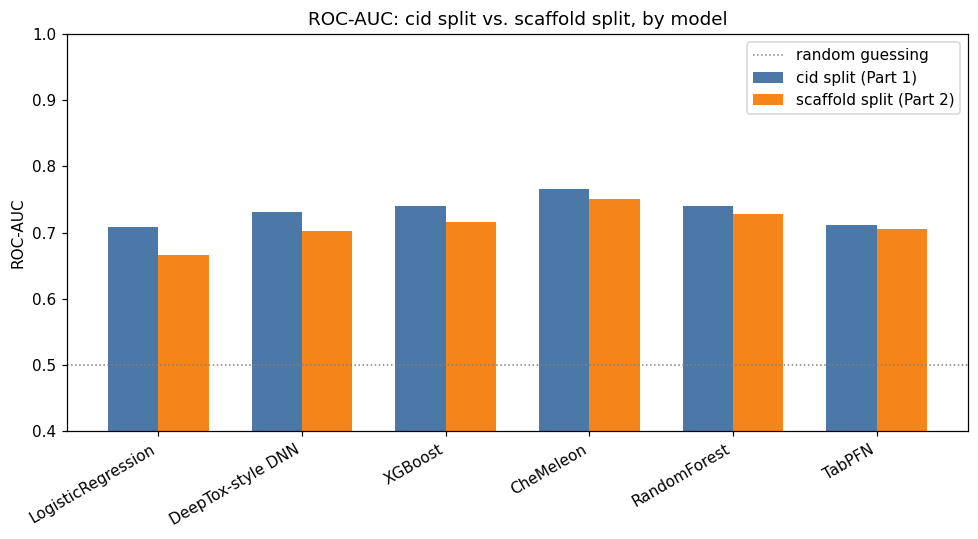

In [39]:
cid_split_df = pd.DataFrame(results).set_index("model")[["roc_auc", "pr_auc", "balanced_accuracy", "f1"]]
scaffold_split_df = pd.DataFrame(results_scaffold).set_index("model")[["roc_auc", "pr_auc", "balanced_accuracy", "f1"]]

comparison = cid_split_df.join(scaffold_split_df, lsuffix="_cid_split", rsuffix="_scaffold_split")
comparison["roc_auc_drop"] = comparison["roc_auc_cid_split"] - comparison["roc_auc_scaffold_split"]
comparison = comparison.sort_values("roc_auc_drop", ascending=False)
print(comparison[["roc_auc_cid_split", "roc_auc_scaffold_split", "roc_auc_drop"]].round(3))

fig, ax = plt.subplots(figsize=(9, 5))
model_order = comparison.index.tolist()
x = np.arange(len(model_order))
width = 0.35
ax.bar(x - width / 2, comparison.loc[model_order, "roc_auc_cid_split"], width, label="cid split (Part 1)", color="#4C78A8")
ax.bar(x + width / 2, comparison.loc[model_order, "roc_auc_scaffold_split"], width, label="scaffold split (Part 2)", color="#F58518")
ax.axhline(0.5, color="gray", ls=":", lw=1, label="random guessing")
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=30, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.4, 1.0)
ax.set_title("ROC-AUC: cid split vs. scaffold split, by model")
ax.legend()
plt.tight_layout()
plt.show()